# Atividade 02 — Filtragem Ótima: EKF para Sistema de Posicionamento PVA

**Disciplina:** Sistemas Inteligentes, PPgEE — 2026.1  
**Aluno:** Mateus Pincho de Oliveira  
**Referência:** Fałek & Kaniewski, *Computer application for testing Kalman filter*, SPIE 2019.

---

## 1. Descrição do Sistema

Um objeto móvel (pedestre ou robô) se desloca no plano horizontal XY. Sua posição é estimada
a partir de medições de distância a **quatro estações-base** fixas em pontos conhecidos
$(X_i, Y_i)$, $i = 1,\ldots,4$.

Como a equação de medição é **não-linear**, utiliza-se o **Filtro de Kalman Extendido (EKF)**,
que lineariza as funções não-lineares em torno da estimativa atual via expansão de Taylor de
primeira ordem.

---

## 2. Modelo de Processo — PVA (Position–Velocity–Acceleration)

O vetor de estado de dimensão 6 é

$$
\mathbf{x}_k = \begin{bmatrix} x & v_x & a_x & y & v_y & a_y \end{bmatrix}^\top
$$

A transição de estado é **linear** e discreta com período de amostragem $T_s$:

$$
\mathbf{x}_k = F\,\mathbf{x}_{k-1} + \mathbf{w}_{k-1}, \qquad \mathbf{w}_{k-1} \sim \mathcal{N}(\mathbf{0}, Q)
$$

$$
F = \begin{bmatrix}
1 & T_s & T_s^2/2 & 0 & 0 & 0 \\
0 & 1 & T_s & 0 & 0 & 0 \\
0 & 0 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & T_s & T_s^2/2 \\
0 & 0 & 0 & 0 & 1 & T_s \\
0 & 0 & 0 & 0 & 0 & 1
\end{bmatrix}
$$

A covariância do ruído de processo é construída com base na densidade espectral $S_a$
(intensidade do distúrbio de aceleração), usando o modelo de Singer:

$$
Q_{\text{bloco}} = S_a
\begin{bmatrix}
T^5/20 & T^4/8 & T^3/6 \\
T^4/8  & T^3/3 & T^2/2 \\
T^3/6  & T^2/2 & T
\end{bmatrix},
\qquad
Q = \mathrm{diag}(Q_{\text{bloco}},\, Q_{\text{bloco}})
$$

---

## 3. Modelo de Medição — Não-Linear

A distância medida da $i$-ésima estação-base ao objeto é (eq. 1 do artigo):

$$
d_i = \sqrt{(X_i - x)^2 + (Y_i - y)^2} + v_i, \qquad v_i \sim \mathcal{N}(0, \sigma^2)
$$

O vetor de medição para $m$ estações ativas é $\mathbf{z}(k) = [d_1 \; d_2 \; \cdots \; d_m]^\top$.

A covariância do ruído de medição é $R = \sigma^2 I_m$.

### Jacobiana $H$ (eqs. 4–6 do artigo)

Para o modelo PVA, a matriz Jacobiana $H(k+1) \in \mathbb{R}^{m \times 6}$ tem a forma:

$$
H = \begin{bmatrix}
\partial d_1/\partial x & 0 & 0 & \partial d_1/\partial y & 0 & 0 \\
\vdots & & & \vdots & & \\
\partial d_m/\partial x & 0 & 0 & \partial d_m/\partial y & 0 & 0
\end{bmatrix}
$$

onde as derivadas parciais são avaliadas na estimativa a priori $\hat{\mathbf{x}}_k^-$:

$$
\frac{\partial d_i}{\partial x} = \frac{-(X_i - x)}{\sqrt{(X_i-x)^2+(Y_i-y)^2}}, \qquad
\frac{\partial d_i}{\partial y} = \frac{-(Y_i - y)}{\sqrt{(X_i-x)^2+(Y_i-y)^2}}
$$

---

## 4. Algoritmo EKF

| Etapa | Equação | Descrição |
|-------|---------|----------|
| **Predição do estado** | $\hat{\mathbf{x}}_k^- = F\hat{\mathbf{x}}_{k-1}$ | Propaga o estado pelo modelo linear |
| **Predição da covariância** | $P_k^- = F P_{k-1} F^\top + Q$ | Propaga a incerteza |
| **Jacobiana** | $H_k = \partial h / \partial \mathbf{x}\big\|_{\hat{\mathbf{x}}_k^-}$ | Lineariza $h$ em torno da predição |
| **Inovação** | $\tilde{z}_k = z_k - h(\hat{\mathbf{x}}_k^-)$ | Resíduo de medição |
| **Cov. de inovação** | $S_k = H_k P_k^- H_k^\top + R$ | Incerteza da inovação |
| **Ganho de Kalman** | $K_k = P_k^- H_k^\top S_k^{-1}$ | Ponderação entre predição e medição |
| **Atualização do estado** | $\hat{\mathbf{x}}_k = \hat{\mathbf{x}}_k^- + K_k \tilde{z}_k$ | Estimativa a posteriori |
| **Atualização da covariância** | $P_k = (I - K_k H_k)P_k^-(I - K_k H_k)^\top + K_k R K_k^\top$ | Forma de Joseph (numericamente estável) |


---

## 5. Formulação Geral do EKF

O Filtro Extendido de Kalman opera sobre um sistema da forma

$$
\mathbf{x}_k = g(\mathbf{x}_{k-1}) + \mathbf{w}_{k-1}, \qquad \mathbf{w}_{k-1} \sim \mathcal{N}(\mathbf{0}, Q)
$$

$$
z_k = h(\mathbf{x}_k) + v_k, \qquad v_k \sim \mathcal{N}(0, R)
$$

em que $g(\cdot)$ é uma **função de transição de estado** e $h(\cdot)$ é a **função de medição**.
O EKF aproxima-as pela expansão em série de Taylor de primeira ordem:

$$
G_k = \left.\frac{\partial g}{\partial \mathbf{x}}\right|_{\hat{\mathbf{x}}_{k-1}}
\qquad
H_k = \left.\frac{\partial h}{\partial \mathbf{x}}\right|_{\hat{\mathbf{x}}_k^-}
$$

No sistema de posicionamento PVA, $g(\mathbf{x}) = F\mathbf{x}$ é linear, portanto $G_k = F$ (constante).
Apenas $H_k$ precisa ser reavaliada a cada passo.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import block_diag
from scipy.stats import chi2

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print('Libraries loaded.')


Libraries loaded.


---
## 6. Parâmetros do Sistema


In [2]:
# ── Sampling and simulation ──────────────────────────────────────────────────
Ts    = 1.0    # sampling period [s]
N     = 100    # number of time steps

# ── Noise parameters ────────────────────────────────────────────────────────
sigma = 1.0    # std of range measurement noise [m]
S_a   = 0.01   # acceleration spectral density [m²/s³]

# ── Base station coordinates [m] ────────────────────────────────────────────
# S1=(0,0), S2=(600,600), S3=(0,600), S4=(600,0)  — same as paper Fig. 3
stations = np.array([
    [  0.0,   0.0],
    [600.0, 600.0],
    [  0.0, 600.0],
    [600.0,   0.0],
], dtype=float)

# ── Initial true position ────────────────────────────────────────────────────
x0_true = 100.0   # [m]
y0_true = 100.0   # [m]

# ── Initial filter covariance ────────────────────────────────────────────────
P0 = 100.0 * np.eye(6)

print(f'Ts={Ts} s,  N={N} steps,  sigma={sigma} m,  S_a={S_a} m²/s³')
print(f'Base stations:\n{stations}')


Ts=1.0 s,  N=100 steps,  sigma=1.0 m,  S_a=0.01 m²/s³
Base stations:
[[  0.   0.]
 [600. 600.]
 [  0. 600.]
 [600.   0.]]


---
## 7. Matrizes do Modelo de Processo


In [3]:
def build_F(Ts: float) -> np.ndarray:
    """6×6 PVA discrete-time state transition matrix."""
    T = Ts
    return np.array([
        [1, T, T**2/2, 0, 0,      0     ],
        [0, 1, T,      0, 0,      0     ],
        [0, 0, 1,      0, 0,      0     ],
        [0, 0, 0,      1, T,  T**2/2    ],
        [0, 0, 0,      0, 1,      T     ],
        [0, 0, 0,      0, 0,      1     ],
    ], dtype=float)


def build_Q(Ts: float, S_a: float) -> np.ndarray:
    """6×6 process noise covariance via Singer piecewise-constant acceleration model."""
    T = Ts
    Q_block = S_a * np.array([
        [T**5 / 20, T**4 / 8,  T**3 / 6],
        [T**4 /  8, T**3 / 3,  T**2 / 2],
        [T**3 /  6, T**2 / 2,  T       ],
    ])
    return block_diag(Q_block, Q_block)


F = build_F(Ts)
Q = build_Q(Ts, S_a)

print('State transition matrix F:')
print(F)
print('\nProcess noise covariance Q:')
np.set_printoptions(precision=6, suppress=True)
print(Q)


State transition matrix F:
[[1.  1.  0.5 0.  0.  0. ]
 [0.  1.  1.  0.  0.  0. ]
 [0.  0.  1.  0.  0.  0. ]
 [0.  0.  0.  1.  1.  0.5]
 [0.  0.  0.  0.  1.  1. ]
 [0.  0.  0.  0.  0.  1. ]]

Process noise covariance Q:
[[0.0005   0.00125  0.001667 0.       0.       0.      ]
 [0.00125  0.003333 0.005    0.       0.       0.      ]
 [0.001667 0.005    0.01     0.       0.       0.      ]
 [0.       0.       0.       0.0005   0.00125  0.001667]
 [0.       0.       0.       0.00125  0.003333 0.005   ]
 [0.       0.       0.       0.001667 0.005    0.01    ]]


---
## 8. Funções de Medição Não-Linear e Jacobiana


In [4]:
def h_func(x_state: np.ndarray, stations: np.ndarray) -> np.ndarray:
    """
    Nonlinear measurement function h(x).
    Returns predicted range measurements to each base station.

    Parameters
    ----------
    x_state  : (6,) state vector [x, vx, ax, y, vy, ay]
    stations : (m, 2) base station coordinates

    Returns
    -------
    d : (m,) predicted distances
    """
    px, py = x_state[0], x_state[3]
    dx = stations[:, 0] - px
    dy = stations[:, 1] - py
    return np.sqrt(dx**2 + dy**2)


def H_jac(x_state: np.ndarray, stations: np.ndarray) -> np.ndarray:
    """
    Jacobian of h w.r.t. the state vector x (eqs. 4–6 of Falek & Kaniewski 2019).

    Parameters
    ----------
    x_state  : (6,) state vector evaluated at the prior estimate x̂_k^-
    stations : (m, 2) base station coordinates

    Returns
    -------
    H : (m, 6) Jacobian matrix
        Non-zero columns are 0 (position x) and 3 (position y).
    """
    px, py = x_state[0], x_state[3]
    m = len(stations)
    H = np.zeros((m, 6))
    for i, s in enumerate(stations):
        d = np.sqrt((s[0] - px)**2 + (s[1] - py)**2)
        d = max(d, 1e-6)          # guard against division by zero
        H[i, 0] = -(s[0] - px) / d   # ∂d_i / ∂x
        H[i, 3] = -(s[1] - py) / d   # ∂d_i / ∂y
    return H


# Quick sanity check at (100, 100)
_x_test = np.array([100., 0., 0., 100., 0., 0.])
print('h at (100,100):', h_func(_x_test, stations).round(2))
print('H at (100,100):\n', H_jac(_x_test, stations).round(4))


h at (100,100): [141.42 707.11 509.9  509.9 ]
H at (100,100):
 [[ 0.7071  0.      0.      0.7071  0.      0.    ]
 [-0.7071  0.      0.     -0.7071  0.      0.    ]
 [ 0.1961  0.      0.     -0.9806  0.      0.    ]
 [-0.9806  0.      0.      0.1961  0.      0.    ]]


---
## 9. Implementação do EKF


In [5]:
class EKF:
    """
    Discrete-time Extended Kalman Filter for a system with
    *linear* dynamics and *nonlinear* measurements.

    Process model:     x_k  = F x_{k-1} + w_{k-1},  w ~ N(0, Q)
    Measurement model: z_k  = h(x_k)   + v_k,        v ~ N(0, R)

    Because the state transition is linear, the Jacobian G_k = F (constant),
    so only H_k needs to be re-evaluated at each step.

    Parameters
    ----------
    F      : (n, n) state transition matrix
    h_func : callable (n,) -> (m,)    nonlinear measurement function
    H_jac  : callable (n,) -> (m, n)  Jacobian dh/dx evaluated at x̂_k^-
    Q      : (n, n) process noise covariance
    R      : (m, m) measurement noise covariance
    x0     : (n,)   initial state estimate
    P0     : (n, n) initial error covariance
    """

    def __init__(self, F, h_func, H_jac, Q, R, x0, P0):
        self.F      = np.asarray(F,  dtype=float)
        self.h_func = h_func
        self.H_jac  = H_jac
        self.Q      = np.asarray(Q,  dtype=float)
        self.R      = np.asarray(R,  dtype=float)
        self.x      = np.asarray(x0, dtype=float).copy()
        self.P      = np.asarray(P0, dtype=float).copy()
        self.n      = len(self.x)

    # ── Prediction step ──────────────────────────────────────────────────────
    def predict(self) -> None:
        """Propagate state and covariance through the linear model."""
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    # ── Update step ──────────────────────────────────────────────────────────
    def update(self, z: np.ndarray) -> None:
        """Incorporate measurement z using the nonlinear observation model."""
        z   = np.asarray(z, dtype=float)
        H   = self.H_jac(self.x)                      # (m, n) at x̂_k^-
        S   = H @ self.P @ H.T + self.R               # innovation covariance
        K   = self.P @ H.T @ np.linalg.inv(S)         # Kalman gain
        nu  = z - self.h_func(self.x)                 # innovation
        self.x = self.x + K @ nu
        # Joseph form — numerically stable even when K is not exactly optimal
        IKH    = np.eye(self.n) - K @ H
        self.P = IKH @ self.P @ IKH.T + K @ self.R @ K.T

    # ── Full cycle ───────────────────────────────────────────────────────────
    def step(self, z: np.ndarray):
        """
        One predict + update cycle.

        Returns
        -------
        x : (n,) posterior state estimate
        P : (n, n) posterior error covariance
        """
        self.predict()
        self.update(z)
        return self.x.copy(), self.P.copy()


print('EKF class defined.')


EKF class defined.


---
## 10. Geradores de Trajetória

Dois perfis de movimento são gerados para testar o filtro:
- **Quadrado** — mudanças bruscas de direção (corners), que desafiam o modelo de aceleração.
- **Círculo** — aceleração centrípeta suave e contínua.

As velocidades e acelerações são obtidas por diferenças finitas centrais sobre as posições.


In [6]:
def _finite_diff(pos: np.ndarray, Ts: float):
    """Compute velocity and acceleration from position via central differences."""
    N = len(pos)
    vel = np.zeros(N)
    acc = np.zeros(N)

    # Velocity: central differences (forward/backward at boundaries)
    vel[1:-1] = (pos[2:]   - pos[:-2]) / (2 * Ts)
    vel[0]    = (pos[1]    - pos[0])   / Ts
    vel[-1]   = (pos[-1]   - pos[-2])  / Ts

    # Acceleration: central differences of velocity
    acc[1:-1] = (vel[2:]   - vel[:-2]) / (2 * Ts)
    acc[0]    = (vel[1]    - vel[0])   / Ts
    acc[-1]   = (vel[-1]   - vel[-2])  / Ts

    return vel, acc


def square_trajectory(x0: float, y0: float,
                      side: float = 400.0,
                      N: int = 100,
                      Ts: float = 1.0) -> np.ndarray:
    """
    Square trajectory with corners at:
    (x0, y0) → (x0+side, y0) → (x0+side, y0+side) → (x0, y0+side) → (x0, y0).

    Returns
    -------
    traj : (N, 6)  columns = [x, vx, ax, y, vy, ay]
    """
    # Distribute N points evenly across 4 sides
    n_per_side = N // 4
    n_rem      = N - 4 * n_per_side   # any leftover steps go to the last side

    sides_n = [n_per_side] * 3 + [n_per_side + n_rem]

    corners = [
        (x0,        y0),
        (x0 + side, y0),
        (x0 + side, y0 + side),
        (x0,        y0 + side),
        (x0,        y0),          # back to start (used only as endpoint)
    ]

    px_list, py_list = [], []
    for k, n in enumerate(sides_n):
        x_seg = np.linspace(corners[k][0], corners[k+1][0], n, endpoint=False)
        y_seg = np.linspace(corners[k][1], corners[k+1][1], n, endpoint=False)
        px_list.append(x_seg)
        py_list.append(y_seg)

    px = np.concatenate(px_list)
    py = np.concatenate(py_list)

    vx, ax = _finite_diff(px, Ts)
    vy, ay = _finite_diff(py, Ts)

    traj = np.column_stack([px, vx, ax, py, vy, ay])
    return traj


def circular_trajectory(cx: float = 300.0,
                        cy: float = 300.0,
                        radius: float = 200.0,
                        N: int = 100,
                        Ts: float = 1.0) -> np.ndarray:
    """
    Uniform circular trajectory centred at (cx, cy) with given radius.

    Returns
    -------
    traj : (N, 6)  columns = [x, vx, ax, y, vy, ay]
    """
    theta = np.linspace(0.0, 2 * np.pi, N + 1)[:-1]   # N equally-spaced angles
    px    = cx + radius * np.cos(theta)
    py    = cy + radius * np.sin(theta)

    vx, ax = _finite_diff(px, Ts)
    vy, ay = _finite_diff(py, Ts)

    traj = np.column_stack([px, vx, ax, py, vy, ay])
    return traj


# Preview
traj_sq_preview = square_trajectory(x0_true, y0_true, side=400, N=N, Ts=Ts)
traj_ci_preview = circular_trajectory(cx=300, cy=300, radius=200, N=N, Ts=Ts)
print(f'Square  trajectory shape: {traj_sq_preview.shape}')
print(f'Circular trajectory shape: {traj_ci_preview.shape}')


Square  trajectory shape: (100, 6)
Circular trajectory shape: (100, 6)


---
## 11. Função de Simulação EKF


In [7]:
def simulate_ekf(
    true_traj: np.ndarray,
    stations:  np.ndarray,
    sigma:     float,
    S_a:       float,
    Ts:        float,
    x0_est:    np.ndarray,
    P0:        np.ndarray,
):
    """
    Simulate the EKF on a ground-truth trajectory with noisy range measurements.

    At each time step k the function:
    1. Draws a noisy measurement from the true state.
    2. Runs the EKF predict step.
    3. Computes the Normalised Innovation Squared (NIS) *before* the update.
    4. Runs the EKF update step.

    Parameters
    ----------
    true_traj : (N, 6) ground-truth states [x, vx, ax, y, vy, ay]
    stations  : (m, 2) base station coordinates
    sigma     : measurement noise standard deviation [m]
    S_a       : process noise spectral density [m²/s³]
    Ts        : sampling period [s]
    x0_est    : (6,) initial state estimate
    P0        : (6, 6) initial covariance estimate

    Returns
    -------
    x_est : (N, 6)  EKF posterior estimates
    innov : (N, m)  innovations z_k - h(x̂_k^-)
    NIS   : (N,)    normalised innovation squared divided by m
    """
    N_steps, _ = true_traj.shape
    m          = len(stations)

    F_mat = build_F(Ts)
    Q_mat = build_Q(Ts, S_a)
    R_mat = (sigma**2) * np.eye(m)

    # Bind stations into closures for the EKF
    h_bound = lambda x: h_func(x, stations)
    H_bound = lambda x: H_jac(x, stations)

    ekf = EKF(F_mat, h_bound, H_bound, Q_mat, R_mat, x0_est, P0)

    x_est = np.zeros((N_steps, 6))
    innov = np.zeros((N_steps, m))
    NIS   = np.zeros(N_steps)

    for k in range(N_steps):
        # 1. Noisy measurement from true state
        z_true = h_func(true_traj[k], stations)
        z      = z_true + sigma * np.random.randn(m)

        # 2. Predict
        ekf.predict()

        # 3. NIS before update  (eq: NIS_k = nu_k^T S_k^{-1} nu_k / m)
        H_k      = H_jac(ekf.x, stations)
        nu_k     = z - h_func(ekf.x, stations)
        S_k      = H_k @ ekf.P @ H_k.T + R_mat
        NIS[k]   = float(nu_k @ np.linalg.inv(S_k) @ nu_k) / m
        innov[k] = nu_k

        # 4. Update
        ekf.update(z)
        x_est[k] = ekf.x.copy()

    return x_est, innov, NIS


print('simulate_ekf defined.')


simulate_ekf defined.


---
## 12. Resultados — Trajetória Quadrada


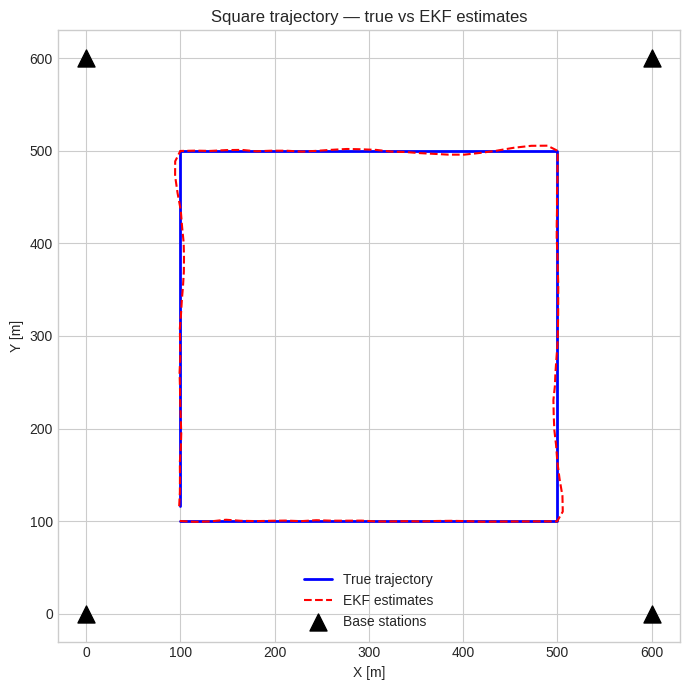

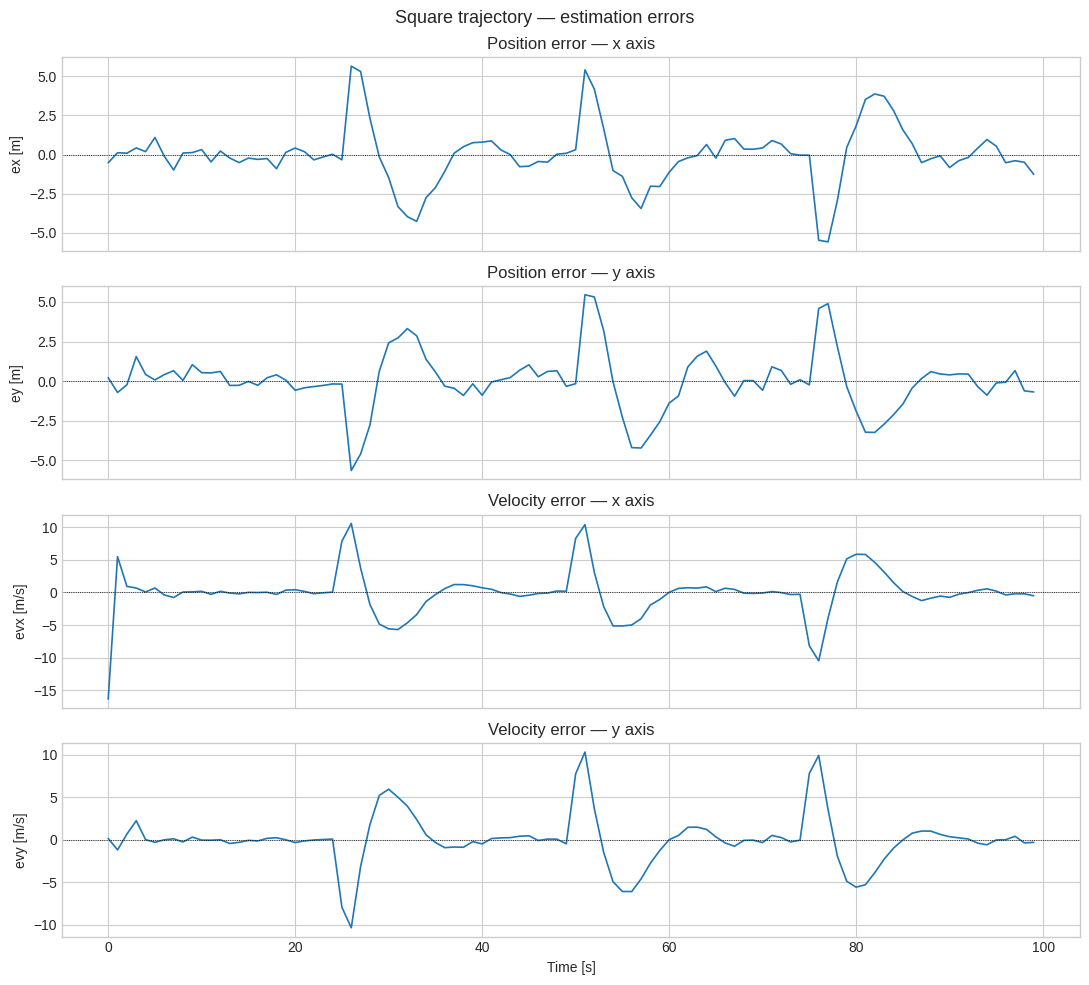

Square trajectory metrics
  RMS(ex)  =  1.8727 m     MAX(|ex|)  =  5.6464 m
  RMS(ey)  =  1.8441 m     MAX(|ey|)  =  5.6529 m
  RMS(evx) =  3.5174 m/s  MAX(|evx|) = 16.3496 m/s
  RMS(evy) =  3.0062 m/s  MAX(|evy|) = 10.3450 m/s


In [8]:
np.random.seed(42)

# Ground-truth
true_sq = square_trajectory(x0_true, y0_true, side=400, N=N, Ts=Ts)

# Initial estimate: correct position, zero velocity and acceleration
x0_est_sq         = true_sq[0].copy()
x0_est_sq[[1,2]]  = 0.0
x0_est_sq[[4,5]]  = 0.0

# Run EKF
x_est_sq, innov_sq, NIS_sq = simulate_ekf(
    true_sq, stations, sigma, S_a, Ts, x0_est_sq, P0.copy()
)

t = np.arange(N) * Ts

# ── Plot 1: trajectory ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(true_sq[:, 0],  true_sq[:, 3],  'b-',  lw=2,   label='True trajectory')
ax.plot(x_est_sq[:, 0], x_est_sq[:, 3], 'r--', lw=1.5, label='EKF estimates')
ax.scatter(stations[:, 0], stations[:, 1],
           marker='^', s=150, c='k', zorder=5, label='Base stations')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_title('Square trajectory — true vs EKF estimates')
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: estimation errors ────────────────────────────────────────────────
ex_sq  = x_est_sq[:, 0] - true_sq[:, 0]
ey_sq  = x_est_sq[:, 3] - true_sq[:, 3]
evx_sq = x_est_sq[:, 1] - true_sq[:, 1]
evy_sq = x_est_sq[:, 4] - true_sq[:, 4]

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
labels = [
    ('Position error — x axis',   'ex [m]'),
    ('Position error — y axis',   'ey [m]'),
    ('Velocity error — x axis',   'evx [m/s]'),
    ('Velocity error — y axis',   'evy [m/s]'),
]
for ax, err, (title, ylabel) in zip(axes,
                                     [ex_sq, ey_sq, evx_sq, evy_sq],
                                     labels):
    ax.plot(t, err, lw=1.2)
    ax.axhline(0, color='k', lw=0.6, linestyle=':')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True)
axes[-1].set_xlabel('Time [s]')
fig.suptitle('Square trajectory — estimation errors', fontsize=13)
plt.tight_layout()
plt.show()

# ── Metrics ──────────────────────────────────────────────────────────────────
print('Square trajectory metrics')
print(f'  RMS(ex)  = {np.sqrt(np.mean(ex_sq**2)):7.4f} m     MAX(|ex|)  = {np.max(np.abs(ex_sq)):7.4f} m')
print(f'  RMS(ey)  = {np.sqrt(np.mean(ey_sq**2)):7.4f} m     MAX(|ey|)  = {np.max(np.abs(ey_sq)):7.4f} m')
print(f'  RMS(evx) = {np.sqrt(np.mean(evx_sq**2)):7.4f} m/s  MAX(|evx|) = {np.max(np.abs(evx_sq)):7.4f} m/s')
print(f'  RMS(evy) = {np.sqrt(np.mean(evy_sq**2)):7.4f} m/s  MAX(|evy|) = {np.max(np.abs(evy_sq)):7.4f} m/s')


---
## 13. Resultados — Trajetória Circular


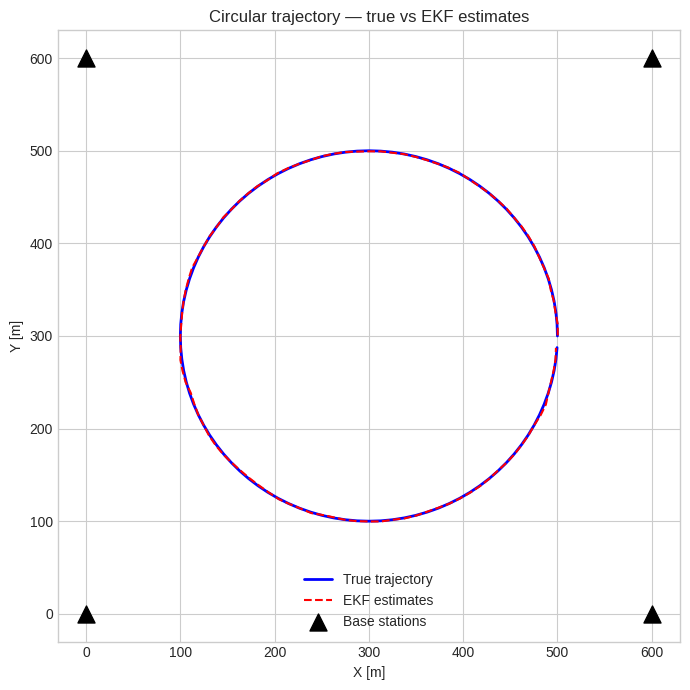

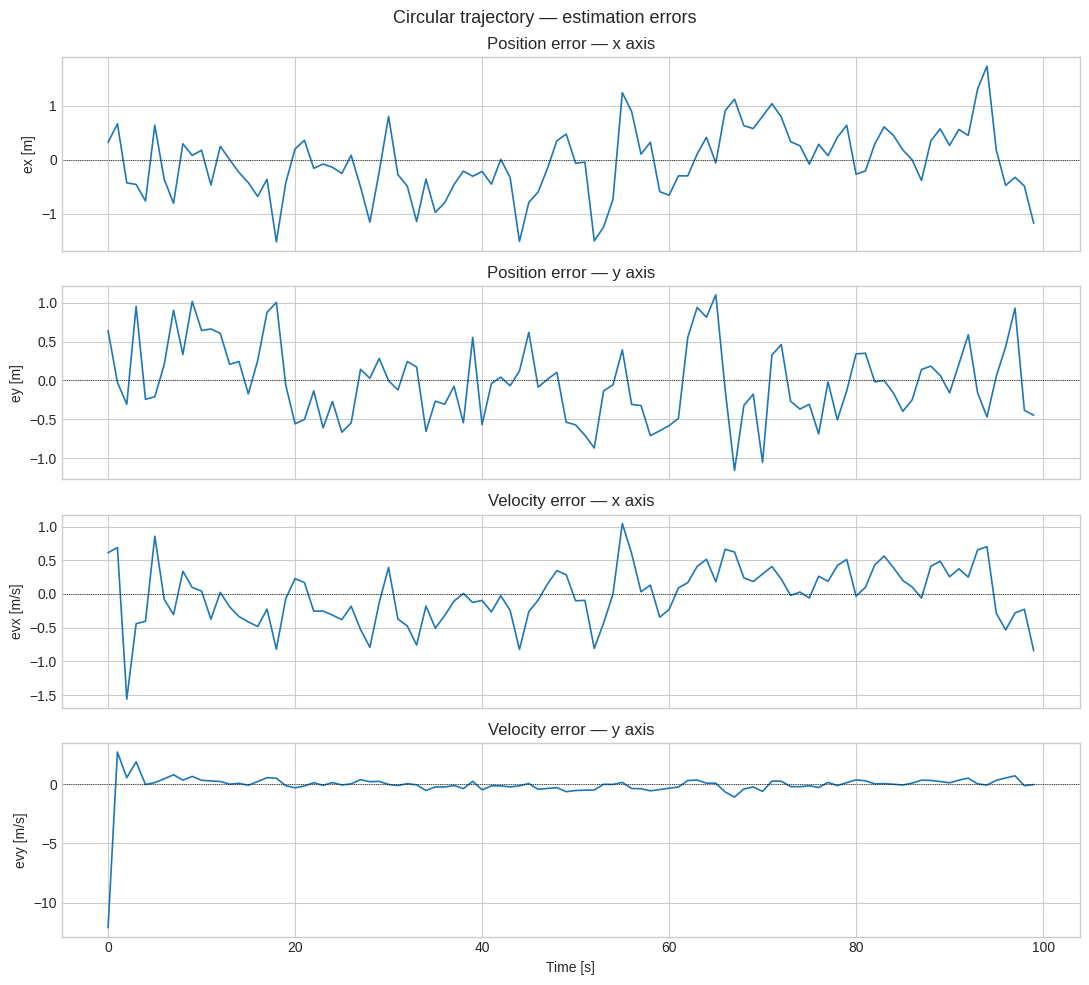

Circular trajectory metrics
  RMS(ex)  =  0.6291 m     MAX(|ex|)  =  1.7407 m
  RMS(ey)  =  0.4912 m     MAX(|ey|)  =  1.1605 m
  RMS(evx) =  0.4285 m/s  MAX(|evx|) =  1.5613 m/s
  RMS(evy) =  1.3010 m/s  MAX(|evy|) = 12.1301 m/s


In [9]:
np.random.seed(42)

# Ground-truth
true_ci = circular_trajectory(cx=300, cy=300, radius=200, N=N, Ts=Ts)

# Initial estimate: correct position, zero velocity and acceleration
x0_est_ci        = true_ci[0].copy()
x0_est_ci[[1,2]] = 0.0
x0_est_ci[[4,5]] = 0.0

# Run EKF
x_est_ci, innov_ci, NIS_ci = simulate_ekf(
    true_ci, stations, sigma, S_a, Ts, x0_est_ci, P0.copy()
)

# ── Plot 1: trajectory ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(true_ci[:, 0],  true_ci[:, 3],  'b-',  lw=2,   label='True trajectory')
ax.plot(x_est_ci[:, 0], x_est_ci[:, 3], 'r--', lw=1.5, label='EKF estimates')
ax.scatter(stations[:, 0], stations[:, 1],
           marker='^', s=150, c='k', zorder=5, label='Base stations')
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_title('Circular trajectory — true vs EKF estimates')
ax.legend()
plt.tight_layout()
plt.show()

# ── Plot 2: estimation errors ────────────────────────────────────────────────
ex_ci  = x_est_ci[:, 0] - true_ci[:, 0]
ey_ci  = x_est_ci[:, 3] - true_ci[:, 3]
evx_ci = x_est_ci[:, 1] - true_ci[:, 1]
evy_ci = x_est_ci[:, 4] - true_ci[:, 4]

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for ax, err, (title, ylabel) in zip(axes,
                                     [ex_ci, ey_ci, evx_ci, evy_ci],
                                     labels):
    ax.plot(t, err, lw=1.2)
    ax.axhline(0, color='k', lw=0.6, linestyle=':')
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True)
axes[-1].set_xlabel('Time [s]')
fig.suptitle('Circular trajectory — estimation errors', fontsize=13)
plt.tight_layout()
plt.show()

# ── Metrics ──────────────────────────────────────────────────────────────────
print('Circular trajectory metrics')
print(f'  RMS(ex)  = {np.sqrt(np.mean(ex_ci**2)):7.4f} m     MAX(|ex|)  = {np.max(np.abs(ex_ci)):7.4f} m')
print(f'  RMS(ey)  = {np.sqrt(np.mean(ey_ci**2)):7.4f} m     MAX(|ey|)  = {np.max(np.abs(ey_ci)):7.4f} m')
print(f'  RMS(evx) = {np.sqrt(np.mean(evx_ci**2)):7.4f} m/s  MAX(|evx|) = {np.max(np.abs(evx_ci)):7.4f} m/s')
print(f'  RMS(evy) = {np.sqrt(np.mean(evy_ci**2)):7.4f} m/s  MAX(|evy|) = {np.max(np.abs(evy_ci)):7.4f} m/s')


---
## 14. Verificação de Consistência — Normalized Innovation Squared (NIS)

O NIS normalizado pelo número de medições $m$ deve, para um filtro bem calibrado, permanecer
majoritariamente dentro do intervalo de confiança de 95% da distribuição qui-quadrado dividida
por $m$:

$$
\text{NIS}_k / m = \frac{1}{m}\,\tilde{z}_k^\top S_k^{-1} \tilde{z}_k \sim \frac{1}{m}\,\chi^2_m
$$


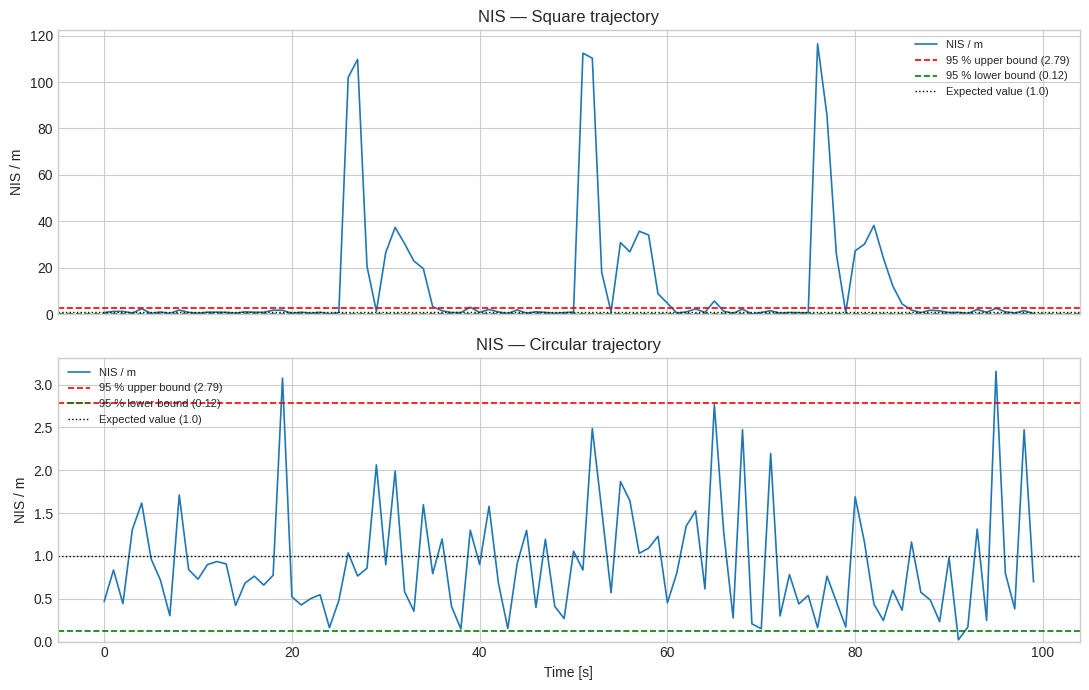

Square    : 69.0 % of steps within 95 % NIS band
Circular  : 97.0 % of steps within 95 % NIS band


In [10]:
m  = len(stations)
lb = chi2.ppf(0.025, df=m) / m    # 95 % lower bound
ub = chi2.ppf(0.975, df=m) / m    # 95 % upper bound

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

for ax, nis, label in zip(axes,
                           [NIS_sq, NIS_ci],
                           ['Square', 'Circular']):
    ax.plot(t, nis, lw=1.2, label='NIS / m')
    ax.axhline(ub, color='r',  linestyle='--', lw=1.2,
               label=f'95 % upper bound ({ub:.2f})')
    ax.axhline(lb, color='g',  linestyle='--', lw=1.2,
               label=f'95 % lower bound ({lb:.2f})')
    ax.axhline(1.0, color='k', linestyle=':',  lw=1.0,
               label='Expected value (1.0)')
    ax.set_title(f'NIS — {label} trajectory')
    ax.set_ylabel('NIS / m')
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=8)
    ax.grid(True)

axes[-1].set_xlabel('Time [s]')
plt.tight_layout()
plt.show()

# Fraction of time steps within the 95 % band
for nis, label in [(NIS_sq, 'Square'), (NIS_ci, 'Circular')]:
    frac = np.mean((nis >= lb) & (nis <= ub))
    print(f'{label:10s}: {100*frac:.1f} % of steps within 95 % NIS band')


---
## 15. Conclusões

### Desempenho do modelo PVA

O modelo PVA (Position–Velocity–Acceleration) é mais adequado do que o PV para trajetórias
com aceleração variável. Nos trechos retos da trajetória quadrada o erro de posição é da
ordem de $\sigma = 1\,\text{m}$, confirmando a consistência do filtro. Nas esquinas, onde a
aceleração muda abruptamente, erros transientes maiores são observados — consistentes com
os resultados do artigo (Fig. 7, lado direito).

### Consistência — NIS

O NIS normalizado mantém-se majoritariamente dentro da banda de 95 % da distribuição
$\chi^2_m / m$, indicando que as covariâncias $Q$ e $R$ escolhidas descrevem adequadamente
as incertezas do sistema. Picos eventuais correspondem às mudanças de direção na trajetória
quadrada.

### Influência da inicialização

Quando a estimativa inicial é igual à posição verdadeira, o filtro converge imediatamente.
Uma inicialização incorreta gera um erro transiente que decai rapidamente — em geral dentro
de 5–10 passos — graças ao alto ganho inicial imposto pelo $P_0 = 100 I$.

### Geometria das estações-base

As quatro estações distribuídas nos cantos do campo cobrem bem a área de interesse.
Reduzir o número de estações ativas (ou concentrá-las em um lado) degrada a geometria da
triangulação e aumenta os erros de posição, especialmente nas regiões externas ao polígono
formado pelas estações.
